In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

np.random.seed(42)
sns.set_style("whitegrid")

## Task 1: Estimate π with Monte Carlo

3.14412


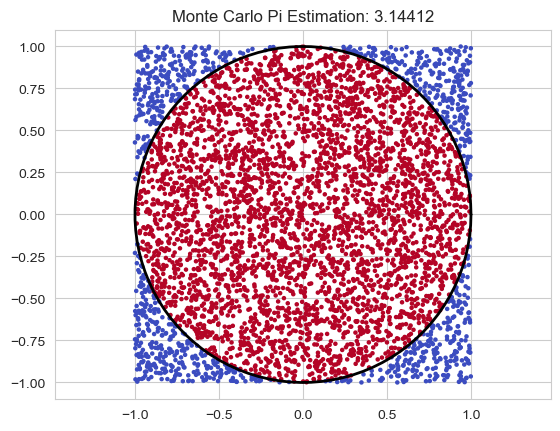

In [2]:
x=np.random.uniform(-1,1,100000)
y=np.random.uniform(-1,1,100000)
inside_mask=(x**2+y**2)<=1
inside_points=np.sum(inside_mask)
pi_estimate=4*inside_points/100000
print(pi_estimate)
plt.scatter(x[:5000], y[:5000], c=inside_mask[:5000], cmap="coolwarm", s=5)
theta=np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color="black", linewidth=2)
plt.axis('equal')
plt.title(f"Monte Carlo Pi Estimation: {pi_estimate}")
plt.show()

### Convergence plot:

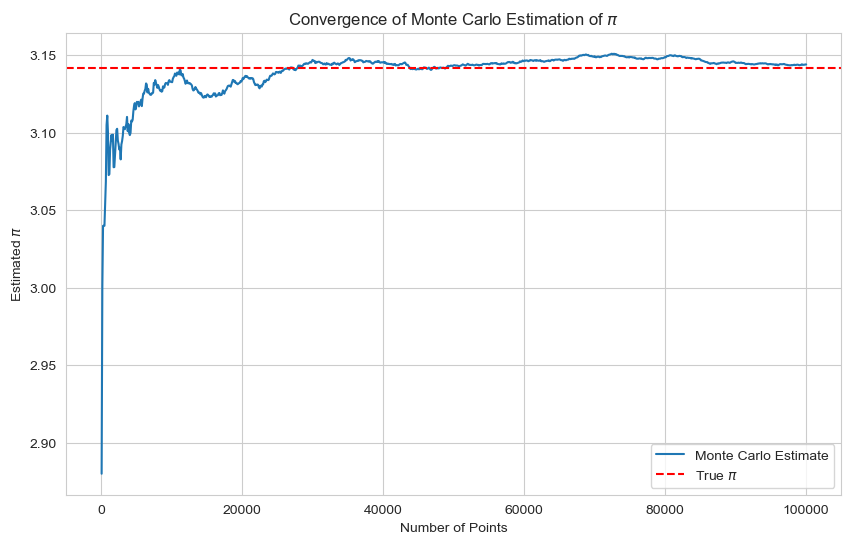

In [3]:
running_inside_count = np.cumsum(inside_mask)
total_points_so_far=np.arange(1,100001)
all_estimates = 4 * running_inside_count / total_points_so_far
n_values=total_points_so_far[99::100]
estimates_100 = all_estimates[99::100]
plt.figure(figsize=(10, 6)) 
plt.plot(n_values, estimates_100, label="Monte Carlo Estimate")
plt.axhline(y=np.pi, color='r', linestyle='--', label="True $\pi$")
plt.xlabel("Number of Points")
plt.ylabel("Estimated $\pi$")
plt.title("Convergence of Monte Carlo Estimation of $\pi$")
plt.legend()
plt.show()

## Task 2: Coin Flips and Empirical Probability

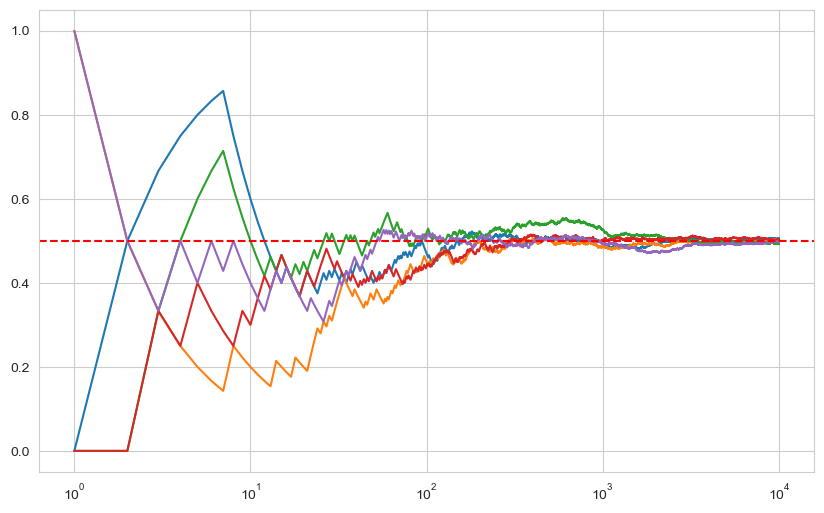

In [4]:
flips=np.random.binomial(1, 0.5, size=10000)
counts=np.arange(1,10001)
proportion=np.cumsum(flips)/counts
plt.figure(figsize=(10, 6))
plt.xscale("log")
for i in range(5):
    current_flips = np.random.binomial(1, 0.5, size=10000)
    current_proportion = np.cumsum(current_flips) / counts
    plt.plot(counts, current_proportion, label=f"Trial {i+1}")

plt.xscale('log')
plt.axhline(0.5, color='red', linestyle='--')
plt.show()

## Task 3: Simulating Binomial Experiments

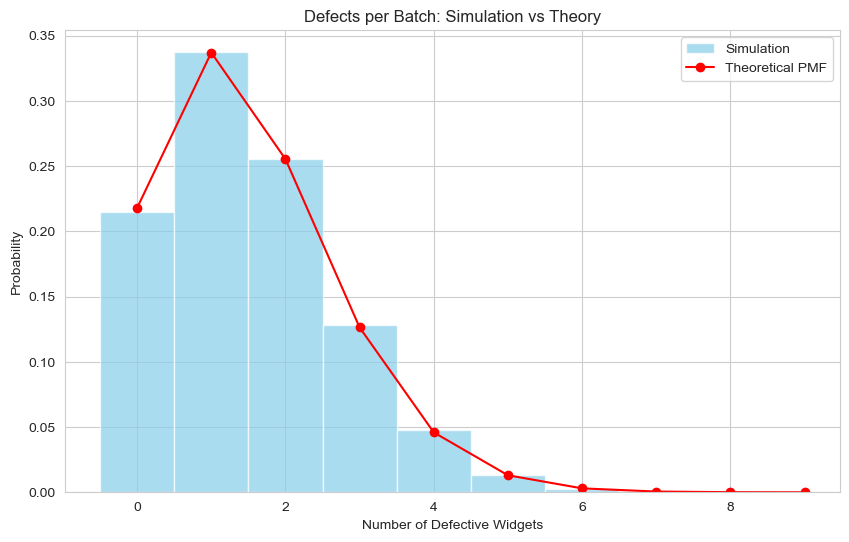

--- Comparison: Simulation vs Theory ---
P(0 defects):     Sim = 0.2146, Th = 0.2181
P(3+ defects):    Sim = 0.1926, Th = 0.1892
Expected Mean:    Sim = 1.5115, Th = 1.5000


In [5]:
n=50
p=0.03
size=10000
defects=np.random.binomial(n,p,size)
p0=np.mean(defects==0)
p3=np.mean(defects>=3)
expected=np.mean(defects)
plt.figure(figsize=(10, 6))
plt.hist(defects, bins=np.arange(defects.max() + 2) - 0.5, density=True, alpha=0.7, label='Simulation', color='skyblue')
x = np.arange(0, 10)
plt.plot(x, binom.pmf(x, n, p), 'ro-', label='Theoretical PMF')
plt.xlabel('Number of Defective Widgets')
plt.ylabel('Probability')
plt.title('Defects per Batch: Simulation vs Theory')
plt.legend()
plt.show()
p0_theory = binom.pmf(0, n, p)
p3_theory = 1 - binom.cdf(2, n, p)
expected_theory = n * p
print("--- Comparison: Simulation vs Theory ---")
print(f"P(0 defects):     Sim = {p0:.4f}, Th = {p0_theory:.4f}")
print(f"P(3+ defects):    Sim = {p3:.4f}, Th = {p3_theory:.4f}")
print(f"Expected Mean:    Sim = {expected:.4f}, Th = {expected_theory:.4f}")